# 01 — Data Exploration

**CineMind Phase 1 · Step 1** — Understand the data before training anything.

Loads MovieLens 100K, computes key statistics, draws exploratory plots, and saves
the cleaned CSV files that every later notebook reads.

**Outputs saved to `data/`:**
`train_positives.csv` · `test_positives.csv` · `items.csv`

Plot saved to `artifacts/eda_overview.png`

In [13]:
import os, sys

# Run from project root regardless of where Jupyter was launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Make src/ importable
if not any('src' in p for p in sys.path):
    sys.path.insert(0, 'src')

import cinemind_utils as cu
print("cwd:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
cu.ensure_dirs()

cwd: c:\Users\shaur\Desktop\My codes shaurya\Content Recommendation system\cinemind _phase1\cinemind_phase1


## 1 · Load the data

In [14]:
ratings = cu.load_ratings()
items   = cu.load_items()
users   = cu.load_users()

n_users  = ratings.user_id.max()
n_movies = ratings.movie_id.max()

print(f"Ratings : {len(ratings):,}")
print(f"Users   : {n_users:,}")
print(f"Movies  : {n_movies:,}")
ratings.head()

Ratings : 100,000
Users   : 943
Movies  : 1,682


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2 · Sparsity and rating distribution

In [15]:
sparsity = 1 - len(ratings) / (n_users * n_movies)
print(f"Sparsity: {sparsity*100:.2f}%  (only {(1-sparsity)*100:.2f}% of the matrix is filled)")

dist = ratings.rating.value_counts().sort_index()
print("\nRating distribution:")
for star, cnt in dist.items():
    print(f"  {star} stars : {cnt:,}  ({cnt/len(ratings)*100:.1f}%)")

pos = (ratings.rating >= 4).sum()
print(f"\nPositives (rating >= 4): {pos:,}  ({pos/len(ratings)*100:.1f}%)  <- what the model learns from")

Sparsity: 93.70%  (only 6.30% of the matrix is filled)

Rating distribution:
  1 stars : 6,110  (6.1%)
  2 stars : 11,370  (11.4%)
  3 stars : 27,145  (27.1%)
  4 stars : 34,174  (34.2%)
  5 stars : 21,201  (21.2%)

Positives (rating >= 4): 55,375  (55.4%)  <- what the model learns from


## 3 · Visualisations

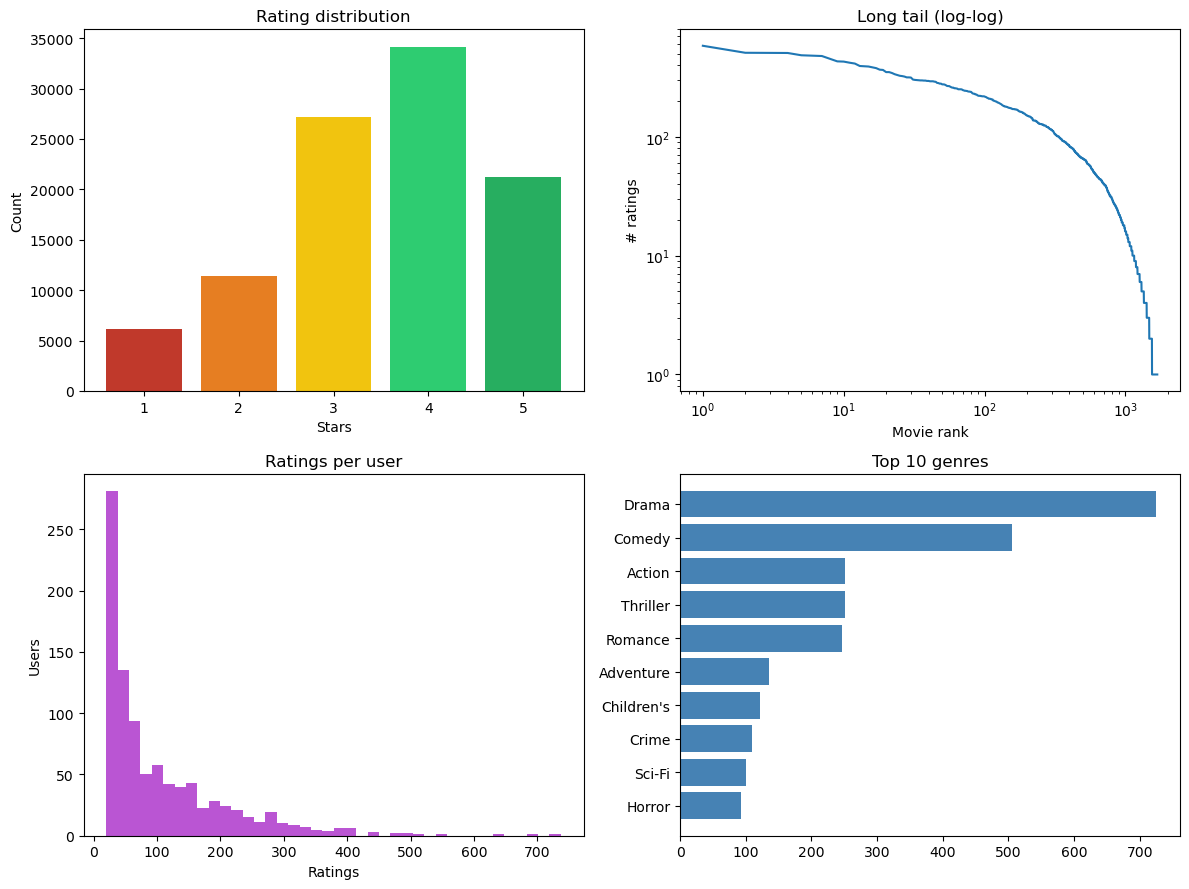

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Rating distribution
axes[0, 0].bar(dist.index, dist.values,
               color=["#c0392b", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"])
axes[0, 0].set_title("Rating distribution")
axes[0, 0].set_xlabel("Stars"); axes[0, 0].set_ylabel("Count")

# Long tail
movie_counts = ratings.groupby("movie_id").size().sort_values(ascending=False)
axes[0, 1].plot(range(1, len(movie_counts) + 1), movie_counts.values)
axes[0, 1].set(xscale="log", yscale="log",
               title="Long tail (log-log)", xlabel="Movie rank", ylabel="# ratings")

# Ratings per user
user_counts = ratings.groupby("user_id").size()
axes[1, 0].hist(user_counts.values, bins=40, color="mediumorchid")
axes[1, 0].set(title="Ratings per user", xlabel="Ratings", ylabel="Users")

# Genre counts
genre_counts = {cu.GENRES[i]: int(items[f"g{i}"].sum())
                for i in range(19) if cu.GENRES[i] != "unknown"}
genre_counts = dict(sorted(genre_counts.items(), key=lambda x: -x[1]))
axes[1, 1].barh(list(genre_counts.keys())[:10],
                list(genre_counts.values())[:10], color="steelblue")
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Top 10 genres")

plt.tight_layout()
plt.savefig(os.path.join(cu.ARTIFACT_DIR, "eda_overview.png"), dpi=120)
plt.show()

## 4 · Cold-start reality check

In [17]:
cold = (movie_counts <= 5).sum()
print(f"Movies with <=5 ratings: {cold}  ({cold/n_movies*100:.1f}%)")
print("Content embeddings (notebook 03) let us still recommend these movies.")

Movies with <=5 ratings: 384  (22.8%)
Content embeddings (notebook 03) let us still recommend these movies.


## 5 · Temporal split and save

We split by **time**, not randomly.  For each user, their most recent 20 % of
interactions become the test set.  A random split would let the model see future
ratings — inflating metrics meaninglessly.

In [18]:
train, test = cu.temporal_split(ratings)

train.to_csv("data/train_positives.csv", index=False)
test.to_csv("data/test_positives.csv",   index=False)
items.to_csv("data/items.csv",           index=False)

print(f"train_positives.csv : {len(train):,} rows")
print(f"test_positives.csv  : {len(test):,} rows")
print(f"items.csv           : {len(items):,} rows")
print("\nNext -> 02_rbm_baseline.ipynb")

train_positives.csv : 44,679 rows
test_positives.csv  : 10,696 rows
items.csv           : 1,682 rows

Next -> 02_rbm_baseline.ipynb
